In [160]:
from graphomaly.preprocessing.egonet import EgonetFeatures
from graphomaly.preprocessing.graph_to_features import graph_to_egonet_features,graph_to_rwalk_features
import networkx as nx
from matplotlib import pyplot as plt
import pandas as pd

In [161]:
G = nx.read_graphml("data/test_graph.graphml",node_type=int)
# directed according to the graphml file
mapping = {old_id: new_id for new_id, old_id in enumerate(G.nodes())}

# Step 2: Relabel the nodes in the graph
G = nx.relabel_nodes(G, mapping)

In [142]:
def get_edges_with_node(graph, node_id):
    # Get all edges in the graph
    all_edges = graph.edges(data=True)
    
    # Filter edges that involve the given node ID
    edges_with_node = [edge for edge in all_edges if node_id in edge[:2]]
    
    return edges_with_node

In [143]:
def plot_ego_graph(G,id):
    egonet = nx.ego_graph(G, id, radius=1, center=True, undirected=True)
    pos = nx.circular_layout(egonet)
    nx.draw(egonet, pos, with_labels=True, node_color='skyblue', node_size=600, font_size=10)
    nx.draw_networkx_edges(egonet, pos, edge_color='black')
    edge_labels = {(u, v): f"{d['cumulated_amount']}" for u, v, d in egonet.edges(data=True)}
    nx.draw_networkx_edge_labels(egonet, pos, edge_labels=edge_labels)
    plt.show()

In [104]:
edges_with_node = get_edges_with_node(G,86)

In [93]:
# Convert nodes and their attributes to a pandas DataFrame
node_data = dict(G.nodes(data=True))


In [94]:
df = pd.DataFrame.from_dict(node_data, orient='index')

In [95]:
df[df['label']>0]

,label
86,1
684,1
1687,1
1725,1
1792,1
...,...
46726,1
46976,1
47131,1
47601,1


In [144]:
# Iterate through each edge and change 'total' to 'cumulated_amount'
for u, v, data in G.edges(data=True):
    if 'total' in data:
        # Assign the value of 'total' to 'cumulated_amount'
        data['cumulated_amount'] = data.pop('total')

for u, v, data in G.edges(data=True):
        data['n_transactions'] = 1

In [106]:
egonet = nx.ego_graph(G, 86, radius=1, center=True, undirected=True)

In [145]:

pos = nx.circulant_graph(egonet)
nx.draw(egonet, pos, with_labels=True, node_color='skyblue', node_size=600, font_size=10)
nx.draw_networkx_edges(egonet, pos, edge_color='black')
edge_labels = {(u, v): f"{d['cumulated_amount']}" for u, v, d in egonet.edges(data=True)}
nx.draw_networkx_edge_labels(egonet, pos, edge_labels=edge_labels)
plt.show()

TypeError: circulant_graph() missing 1 required positional argument: 'offsets'

In [148]:
features,ids,labels=graph_to_egonet_features(G, FULL_egonets=True,  summable_attributes=[], labels=None, verbose=False)

In [149]:
features.loc[46726,:]

f_degree_in                   2.000000
f_degree_out                  3.000000
f_amount_in               58049.000000
f_amount_out             101843.417603
f_nr_trans_in                 2.000000
f_nr_trans_out                3.000000
f_ego_nr_nodes                6.000000
f_ego_nr_edges               10.000000
f_egored_degree_in            2.000000
f_egored_degree_out           2.000000
f_egored_amount_in        58049.000000
f_egored_amount_out       45894.000000
f_egored_nr_trans_in          2.000000
f_egored_nr_trans_out         2.000000
f_egored_nr_nodes             5.000000
f_egored_nr_edges             9.000000
Name: 46726, dtype: float64

In [147]:
result = get_edges_with_node(G,49998)

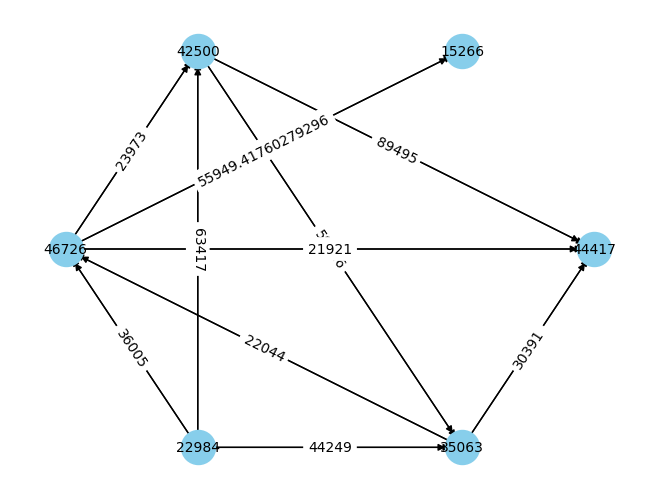

In [138]:
plot_ego_graph(G,46726)

In [ ]:
my_list = ["f_degree_in",'f_degree_out', "f_ego_edge_density", "f_egored_edge_density",
           "f_amount_in", "f_egored_amount_in",'f_amount_out','f_egored_amount_out']
ego = EgonetFeatures()
ego.fit(G,)

In [ ]:
Xf = ego.transform(egonet)

In [150]:
features,ids = graph_to_rwalk_features(G, rwalk_len=15, rwalk_reps=100, 
                                       prob_edge=None, verbose=False)

In [151]:
features

,f_rwalk_start_amount,f_rwalk_transfer_out,f_rwalk_out_back,f_rwalk_out_back_max,f_rwalk_end_amount,f_rwalk_transfer_in,f_rwalk_in_back,f_rwalk_in_back_max
0,32814.753080,12723.298571,0.000000,0.000000,18163.138367,9537.451895,358.616366,10906.238248
1,0.000000,0.000000,0.000000,0.000000,11912.188536,2879.218618,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,6287.124229,3875.109018,0.000000,0.000000
3,33494.053579,3357.203201,561.261305,8280.979091,28200.067993,24490.817549,23.160771,1898.255626
4,0.000000,0.000000,0.000000,0.000000,144438.368843,143333.478507,0.000000,0.000000
...,...,...,...,...,...,...,...,...
49995,499.574386,391.756950,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
49996,3712.777470,1917.609934,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
49997,8598.857905,1868.665319,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
49998,55166.325198,24657.153606,24039.990000,121899.000000,43328.167295,23059.481732,10647.970000,121899.000000


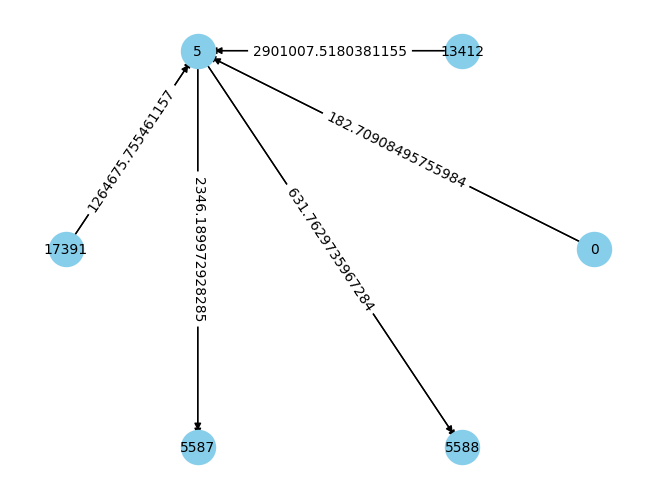

In [159]:
plot_ego_graph(G,5)

In [162]:
from graphomaly.preprocessing.spectrum import SpectrumFeatures


In [163]:
my_list = ["f_spectrum_Laplacian_amount"]
sp = SpectrumFeatures(n_values=3)
sp.fit(G, feature_list=my_list)


SpectrumFeatures(n_values=3)